In [ ]:
# Topic 3: Embeddings

Earlier NLP techniques like Bag of Words and TF-IDF convert text into numbers
based on word frequency. While useful for basic tasks, they fail to capture
semantic meaning and contextual similarity.

Modern language systems require representations that understand meaning,
not just exact word matches. This requirement leads to **Embeddings**.


Traditional NLP representations have key limitations:

1. They rely on exact word matching
2. They cannot recognize synonyms or paraphrases
3. They generate sparse, high-dimensional vectors
4. They do not capture context or relationships between words

For example:
- "AI assistant"
- "Chatbot"

Traditional methods treat them as unrelated,
even though their meanings are very similar.

Embeddings solve this by representing **meaning itself** in numerical form.


Traditional NLP representations have key limitations:

1. They rely on exact word matching
2. They cannot recognize synonyms or paraphrases
3. They generate sparse, high-dimensional vectors
4. They do not capture context or relationships between words

For example:
- "AI assistant"
- "Chatbot"

Traditional methods treat them as unrelated,
even though their meanings are very similar.

Embeddings solve this by representing **meaning itself** in numerical form.


Embeddings are dense numerical representations of text that encode semantic meaning.

In embeddings:
- Each word, sentence, or document is mapped to a fixed-length vector
- The values of the vector are learned from large text corpora
- Similar meanings produce similar vectors

An embedding does not store explicit rules.
Instead, meaning is distributed across multiple dimensions.


### 1. Fixed-Length Representation
Regardless of input length:
- Word
- Sentence
- Paragraph

The output vector has a fixed number of dimensions
(e.g., 300, 768, 1536).

This makes comparison and storage efficient.

### 2. Dense Vectors
Embedding vectors contain mostly non-zero values.
Information is spread across dimensions rather than isolated.

This is fundamentally different from sparse representations like TF-IDF.

### 3. Semantic Similarity
The distance between two embedding vectors represents similarity of meaning.
Closer vectors imply more similar meaning.


Consider three inputs:

Text A: "AI assistant"
Text B: "Chatbot"
Text C: "Weather forecast"

Expected behavior:
- Embedding(A) is close to Embedding(B)
- Embedding(A) is far from Embedding(C)

This closeness is how machines understand similarity.


Embedding("AI assistant"):
[ 0.21, -0.45, 0.78, 0.12, -0.33, 0.56, 0.09, -0.18 ]

Embedding("Chatbot"):
[ 0.19, -0.42, 0.75, 0.10, -0.30, 0.59, 0.11, -0.15 ]

Embedding("Weather forecast"):
[ -0.62, 0.88, -0.14, -0.55, 0.91, -0.20, -0.77, 0.66 ]


Observation:
- The first two vectors are numerically similar
- The third vector is very different
- Numerical closeness corresponds to semantic similarity


# Topic 3: How Embeddings Capture Relationships Between Words and Phrases



---

## Core Idea

Embeddings learn meaning from **context**.

Words or phrases that appear in **similar contexts** in real text
are assigned **similar numerical vectors**.

This idea is often summarized as:

> "You shall know a word by the company it keeps."

---

## What Is Context?

Context means the surrounding words or phrases in which a word appears.

Examples:
- "The AI assistant helps users book appointments"
- "The chatbot helps users answer questions"

Here, **assistant** and **chatbot** appear with similar surrounding words:
- helps
- users
- answers / bookings

Because they appear in similar contexts, the model learns that their meanings are related.

---

## How Relationships Are Learned (Conceptual View)

During training, an embedding model:
1. Reads large amounts of text
2. Observes which words and phrases appear together
3. Adjusts vector values so that similar contexts lead to similar vectors

No rules are written by humans.
The relationships emerge automatically from data.

---

## What "Relationship" Means in Embedding Space

In embedding space:
- Each word or phrase is a point (vector)
- Distance between points represents similarity of meaning

If two vectors are:
- Close → meanings are similar
- Far apart → meanings are different

This is how machines compare meaning numerically.



## Word-Level and Phrase-Level Relationships

Embeddings can capture relationships for:
- Words (e.g., "assistant", "chatbot")
- Phrases (e.g., "AI assistant", "virtual assistant")
- Sentences and paragraphs

Because the model learns from **how full phrases are used**, it can understand
that:
- "AI assistant" and "virtual assistant" are related
- Even though the exact words are different

---

## Why This Is Powerful

Because embeddings capture relationships:
- Exact word matching is not required
- Synonyms and paraphrases can be matched
- Semantic search becomes possible

This is why embeddings are used in:
- Search systems
- Chatbots
- Recommendation systems
- Retrieval-Augmented Generation (RAG)

---

## Simple Summary

- Embeddings are learned from real text data
- Meaning is learned from context
- Similar contexts → similar vectors
- Vector distance represents semantic relationship

This is how embeddings capture relationships between words and phrases.


# Topic 3: Word2Vec and GloVe (Detailed Teaching Notes — No Code)

This notebook is a **teaching reference**:
- simple language
- step-by-step "how it works"
- examples you can say aloud in class
- no math heavy, no code

---

# Part A — Word2Vec (Detailed)

## 1) What problem Word2Vec solves

Earlier methods like BoW/TF-IDF represent text using word frequency.
They fail because:
- they do not capture semantic meaning
- they treat similar words as unrelated
- they require exact word matching

Word2Vec was introduced to learn **dense word vectors** where:
- similar meaning words have similar vectors
- relationships between words become measurable

---

## 2) The key intuition of Word2Vec

> "A word’s meaning can be learned from the words around it."

This is the main principle:
- if two words appear in similar contexts, they likely have similar meanings

Example contexts:
- "The **doctor** treated the patient"
- "The **physician** treated the patient"

Because "doctor" and "physician" appear in similar surrounding words,
Word2Vec learns similar vectors for them.

---

## 3) What "context window" means (very important)

Word2Vec reads sentences and looks at a small window around a word.

Sentence:
"AI assistant helps users book appointments"

If window size = 2, and target word = "assistant":
context words might include: ["AI", "helps", "users"] (depending on position)

So Word2Vec learns from:
(target word, nearby context words)

---

## 4) Two training strategies: CBOW and Skip-gram

Word2Vec training is usually one of these:

### A) CBOW (Continuous Bag of Words)
Goal:
- Use the surrounding words to predict the center word

Example:
Context: ["AI", "helps", "users"]
Predict target: "assistant"

How to explain in class:
- "Given the context words, guess the missing word."

Why it works:
- if the model can predict "assistant" from similar context words,
it learns what "assistant" means.

---

### B) Skip-gram
Goal:
- Use the center word to predict surrounding words

Example:
Input: "assistant"
Predict context: ["AI", "helps", "users"]

How to explain in class:
- "Given a word, guess what words usually appear near it."

Why it works:
- if "assistant" often appears near "helps/users/support",
the model learns this relationship and stores it in the embedding.

---

## 5) How Word2Vec actually learns embeddings (step-by-step)

You can teach it like this:

1. Start with random vectors for each word
2. Read millions of sentences
3. For each training example (CBOW or Skip-gram):
   - the model makes a prediction (initially bad)
4. The model updates word vectors slightly to reduce prediction error
5. After many updates:
   - words that share contexts end up with similar vectors

Important:
- There is no manual rule like "assistant = chatbot"
- it is learned automatically from repeated patterns

---

## 6) Concrete Example: Why "assistant" becomes close to "chatbot"

Training data includes many sentences like:
- "AI assistant helps users"
- "Customer assistant answers questions"
- "Chatbot helps users"
- "Chatbot answers questions"

Common context words:
- helps, users, answers, questions

Because both words repeatedly appear in similar contexts,
their vectors are updated in similar directions.

Result:
Embedding("assistant") becomes close to Embedding("chatbot")

---

## 7) What Word2Vec can capture (two types of relationships)

### (1) Similarity (synonyms / related words)
Examples:
- assistant ≈ chatbot
- doctor ≈ physician
- car ≈ vehicle

This is the "close in space" idea.

---

### (2) Analogy-type relationships (direction patterns)
Classic example:
- king − man + woman ≈ queen

How to explain without math:
- the model learns a consistent "gender shift" pattern in the vector space
- so relationships become directions, not just closeness

---

## 8) Practical limitations of Word2Vec (important to tell students)

### Limitation 1: Static embeddings
One word has one vector always.

Example:
"bank" in:
- "bank account" (finance)
- "bank of river" (nature)

Word2Vec gives the same embedding for "bank" in both cases.
So it cannot resolve context-based meaning.

### Limitation 2: Phrase meaning is not naturally handled
Word2Vec is primarily word-level.
Phrases like "New York" or "AI assistant" need special handling
(phrase models or sentence embeddings later).

---

## 9) Summary of Word2Vec (teaching recap)

- Word2Vec learns word meaning from local context
- CBOW: context → predict word
- Skip-gram: word → predict context
- Similar contexts → similar embeddings
- Limitation: one word = one vector (not context-aware)

---

# Part B — GloVe (Detailed)

## 1) What problem GloVe solves

Word2Vec learns from local context windows (nearby words).
GloVe was introduced with a different idea:

> meaning is also captured by **global statistics** across the entire dataset

GloVe uses the fact that:
- words that appear together frequently across documents are related

---

## 2) Core idea of GloVe in plain words

GloVe learns embeddings using a global co-occurrence table:

- count how often word A appears near word B across the whole corpus
- use these counts to learn vectors

Example:
- "ice" co-occurs with "cold" a lot
- "fire" co-occurs with "hot" a lot

So embeddings reflect these global patterns.

---

## 3) What is "co-occurrence"?

Two words "co-occur" if they appear near each other (within a window),
and this happens many times across a large dataset.

Example:
If we repeatedly see sentences like:
- "cold ice"
- "ice is cold"
- "ice feels cold"

Then "ice" and "cold" have high co-occurrence.

---

## 4) How GloVe learns embeddings (step-by-step working)

You can teach it like this:

1. Scan the entire corpus
2. Build a co-occurrence matrix/table:
   - rows = words
   - columns = context words
   - values = how often they appear together
3. Learn vectors so that:
   - word pairs with high co-occurrence end up closer / aligned in embedding space
4. After training:
   - words with similar co-occurrence patterns get similar embeddings

Important:
- GloVe focuses more on "global summary of statistics"
- Word2Vec focuses more on "predict from local context"

---

## 5) Example: Why GloVe learns meaning well

Suppose across a corpus we observe:

- "king" frequently co-occurs with: royal, palace, crown
- "queen" frequently co-occurs with: royal, palace, crown
- "doctor" frequently co-occurs with: hospital, patient, treatment

Then:
- king and queen become close (similar global patterns)
- doctor becomes far from them (different global pattern)

---

## 6) Word2Vec vs GloVe (simple teaching comparison)

Word2Vec:
- learns by prediction tasks using local context
- "train a small neural model to predict words"

GloVe:
- learns by using global co-occurrence counts
- "learn vectors that match global statistics"

Both create dense vectors that capture semantics.

---

## 7) Limitations of GloVe (same as Word2Vec)

GloVe also produces static embeddings:
- one word always has one vector

So:
- "bank" has one vector even if meaning changes by context

This is why we later move to:
- contextual embeddings (BERT/GPT)
- sentence embeddings

---

## 8) Summary of GloVe (teaching recap)

- GloVe learns from global co-occurrence statistics
- words that co-occur frequently become semantically related
- it produces dense semantic word embeddings
- limitation: static embeddings, not context-aware

---

# Final Bridge Statement (useful to teach)

Word2Vec and GloVe are early semantic embedding models:
- they introduced dense meaning vectors
- they show "context/co-occurrence → meaning"
- but they fail when meaning depends on context

This leads to the next topic:
## Contextual Embeddings (BERT, GPT) — same word, different meaning


# Topic 3: Sentence Embeddings — Representing Entire Sentences

This section explains the idea of sentence embeddings in detail.
It focuses on **what sentence embeddings are, why they are needed,
and the different ways they can be created**, without implementation details.

---

## 1. What Are Sentence Embeddings?

Sentence embeddings represent an **entire sentence (or paragraph)** as a
**single dense numerical vector** that captures its overall meaning.

Instead of creating embeddings for individual words,
the full sentence is converted into **one fixed-length vector**.

Example:
- Sentence → One vector
- Paragraph → One vector

This allows machines to compare **sentences by meaning**.

---

## 2. Why Word Embeddings Are Not Enough

Word embeddings (Word2Vec, GloVe):
- Represent one word at a time
- Do not directly represent sentence meaning
- Cannot reliably compare full sentences

In real-world applications, users interact using:
- Questions
- Commands
- Statements
- Long descriptions

Examples:
- “Book an appointment with the doctor”
- “Schedule a visit with a physician”

Word-level comparison struggles here.
Sentence embeddings solve this problem.

---

## 3. Core Idea of Sentence Embeddings

> The meaning of a sentence is more than the sum of its individual words.

Sentence embeddings:
- Combine information from all words
- Capture intent, semantics, and context
- Produce one vector for the whole sentence

Key principle:
- Similar sentences → similar vectors
- Different sentences → distant vectors

---

## 4. Simple Intuition (Teaching-Friendly)

Think of sentence embeddings like this:

- Letters → form words
- Words → form sentences
- Sentence embedding → represents the whole sentence

Just like a word has meaning beyond letters,
a sentence embedding has meaning beyond individual words.

---

## 5. Example: Why Sentence Embeddings Matter

Consider the following sentences:

Sentence A:
"Book an appointment with the doctor"

Sentence B:
"Schedule a visit with a physician"

Sentence C:
"Check tomorrow's weather forecast"

Even though:
- A and B use different words
- A and B have different structures

Their **meaning is the same**.

Sentence embeddings ensure:
- A ≈ B (close vectors)
- A far from C

This is essential for semantic search and question answering.

---

## 6. Key Properties of Sentence Embeddings

Sentence embeddings have the following properties:

- One sentence → one vector
- Fixed-length representation
- Dense (not sparse like TF-IDF)
- Meaning-focused
- Suitable for similarity comparison (e.g., cosine similarity)

---

## 7. How Sentence Embeddings Are Created (High-Level View)

There are **multiple ways** to create sentence embeddings.
The difference lies in **how meaning is combined and learned**.

Below are the main approaches learners should be aware of.

---

## 8. Method 1: Averaging Word Embeddings (Early Approach)

This is the simplest approach.

How it works:
- Generate embeddings for each word
- Average all word vectors to form a sentence vector

Example:
Sentence: "AI assistant helps users"
→ Average of embeddings for:
AI + assistant + helps + users

Limitations:
- Ignores word order
- Weak semantic representation
- Cannot capture complex sentence meaning

This method is mostly historical.

---

## 9. Method 2: Transformer-Based Sentence Embeddings

Modern systems use **Transformer-based models** to create sentence embeddings.

How this works conceptually:
- The model reads the entire sentence at once
- Each word is interpreted in the context of other words
- The model produces a single vector representing the sentence meaning

Advantages:
- Context-aware
- Captures sentence intent
- Handles paraphrases well

This is the most common approach today.

---

## 10. Method 3: Sentence Transformers (Specialized Models)

Sentence Transformers are **Transformer-based models**
specifically trained for sentence similarity tasks.

Key idea:
- They are trained so that:
  - Similar sentences → closer vectors
  - Dissimilar sentences → farther vectors

Example training intuition:
- (“Book doctor appointment”, “Schedule doctor visit”) → close
- (“Book doctor appointment”, “Weather forecast”) → far

This makes them highly effective for:
- Semantic search
- Question matching
- RAG systems

---

## 11. Method 4: API-Based Embedding Models

Many modern applications use **pretrained embedding APIs**.

Examples:
- OpenAI embedding models
- Azure OpenAI embeddings
- Cohere embeddings

How they work:
- Input: sentence or paragraph
- Output: dense vector representing meaning

Advantages:
- No training required
- Production-ready
- Optimized for large-scale systems

These APIs usually generate **sentence or document embeddings by default**.

---

## 12. Comparison of Sentence Embedding Methods (Conceptual)

- Averaging word embeddings → simple but weak
- Transformer-based models → strong semantic understanding
- Sentence Transformers → optimized for similarity
- API-based models → easiest for production use

Modern GenAI systems primarily rely on:
- Transformer-based sentence embeddings

---

## 13. Where Sentence Embeddings Are Used

Sentence embeddings are used in:
- Semantic search
- Question answering
- Chatbots
- Recommendation systems
- Retrieval-Augmented Generation (RAG)

They enable machines to retrieve information based on **meaning**, not keywords.

---

## 14. Teaching Summary (Use This in Class)

- Sentence embeddings represent the meaning of an entire sentence
- Similar sentences produce similar vectors
- Multiple methods exist to create them
- Transformer-based models are the most effective today
- Sentence embeddings are foundational for modern GenAI systems

---

## 15. Bridge to Next Topic

Sentence embeddings naturally lead to the next question:

> What happens when the same word has different meanings in different sentences?

This leads to:
## Contextual Embeddings (BERT, GPT)


# Contextual Embeddings (BERT, GPT) — Same Word, Different Meanings

This section explains **what contextual embeddings are, why they are needed,
and how they work at a high level**, using simple examples.
No architecture or mathematical details are required at this stage.

---

## 1. Why Contextual Embeddings Are Needed

Early embedding models such as **Word2Vec** and **GloVe** assign:
- one fixed vector to each word
- regardless of how the word is used in a sentence

This creates a major problem when words have **multiple meanings**.

Example:
- "bank account"
- "bank of the river"

In both sentences, the word **"bank"** has different meanings.
However, early models represent "bank" using the **same embedding**,
which leads to incorrect understanding.

---

## 2. What Are Contextual Embeddings?

**Contextual embeddings generate word representations based on the entire sentence.**

This means:
- A word does not have a single fixed vector
- Its embedding depends on the surrounding words
- The same word can have **different vectors in different contexts**

In other words:
> Meaning is determined by context, not by the word alone.

---

## 3. Core Idea of Contextual Embeddings

Contextual embedding models:
- Read the **entire sentence**
- Understand relationships between words
- Decide what a word means in that specific sentence
- Generate an embedding that reflects that meaning

The embedding of a word changes dynamically based on context.

---

## 4. Simple Intuition

Think of contextual embeddings like human understanding.

When humans read a sentence:
- They do not interpret words in isolation
- They use surrounding words to infer meaning

Contextual embedding models work in a similar way:
- They look at all words together
- They assign meaning based on usage

---

## 5. Example: Same Word, Different Embeddings

Consider these two sentences:

Sentence 1:
"I deposited money in the bank."

Sentence 2:
"The boat is near the bank of the river."

Although the word **"bank"** appears in both sentences:
- In Sentence 1, it refers to a financial institution
- In Sentence 2, it refers to the side of a river

Contextual embedding models generate:
- One embedding for "bank" in Sentence 1 (financial meaning)
- A different embedding for "bank" in Sentence 2 (geographical meaning)

This difference allows machines to correctly understand intent.

---

## 6. How Contextual Embeddings Work (High-Level)

At a high level, contextual embedding models work as follows:

1. The model reads the full sentence
2. Each word is interpreted using information from surrounding words
3. Relationships between words are analyzed
4. The model generates embeddings that reflect contextual meaning

There are no fixed word vectors.
Instead, embeddings are **computed dynamically** based on context.

---

## 7. Role of BERT and GPT (High-Level)

Models like **BERT** and **GPT** are commonly used to generate contextual embeddings.

### BERT (High-Level Understanding)
- Designed for language understanding
- Reads the entire sentence together
- Produces context-aware embeddings
- Useful for:
  - Search
  - Classification
  - Sentence embeddings

---

### GPT (High-Level Understanding)
- Designed for text generation
- Reads text sequentially
- Generates context-aware embeddings internally
- Useful for:
  - Chatbots
  - Text generation
  - Answer generation in RAG

At this stage, we focus on **what they enable**, not their internal architecture.

---

## 8. Why Contextual Embeddings Are Powerful

Contextual embeddings enable:
- Accurate word sense disambiguation
- Better semantic similarity
- Improved search and retrieval
- Strong performance in modern NLP and GenAI systems

They overcome the major limitations of static word embeddings.

---

## 9. Teaching Summary

- Early embeddings are static and context-independent
- Contextual embeddings depend on the full sentence
- The same word can have different embeddings in different contexts
- Models like BERT and GPT make this possible
- Contextual embeddings are essential for modern language understanding

---

## 10. Bridge to Next Topic

Contextual embeddings naturally lead to the question:
- How do we use embeddings to retrieve relevant information?

This leads to the next topic:
## Why Embeddings Are Crucial for RAG — Foundation for Semantic Retrieval


Cosine Similarity — Measuring Semantic Closeness

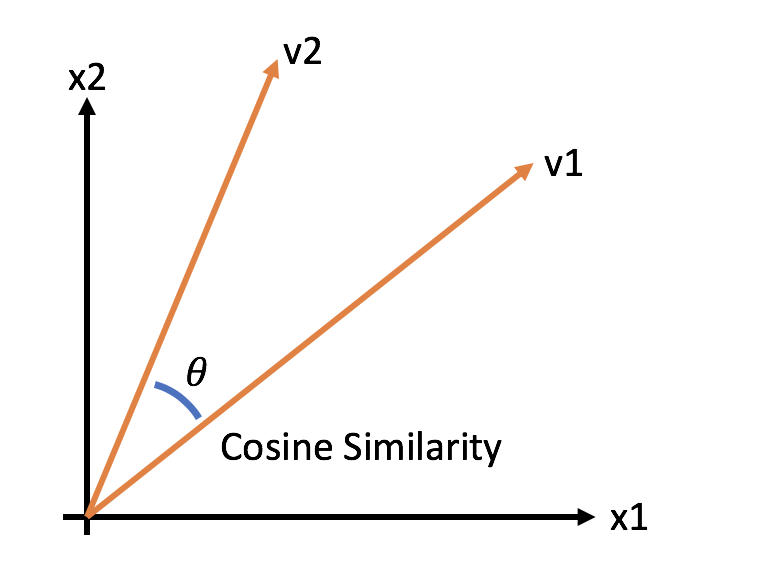


## 1) What is Cosine Similarity?

Cosine similarity is a method to measure how similar two vectors are by looking at the **angle** between them.

- If two vectors point in the **same direction**, they are considered **similar**
- If they point in **different directions**, they are considered **less similar**

This is widely used to compare:
- word embeddings
- sentence embeddings
- document embeddings

---

## 2) How to Read the Diagram (Important)

In your diagram:

- **x1** and **x2** are just two dimensions of a vector space  
  (real embeddings have hundreds or thousands of dimensions, but we visualize in 2D)
- **v1** is the embedding vector for text 1  
  Example: v1 = Embedding("AI assistant")
- **v2** is the embedding vector for text 2  
  Example: v2 = Embedding("Chatbot")
- **θ (theta)** is the angle between **v1** and **v2**

The key point:
> Cosine similarity depends on **θ**, not on the vector length.

---

## 3) Core Intuition (What learners must remember)

### Smaller angle → higher similarity
If **θ is small**:
- v1 and v2 point in nearly the same direction
- cosine similarity is **high**
- meaning is **similar**

### Larger angle → lower similarity
If **θ is large**:
- v1 and v2 point in different directions
- cosine similarity is **low**
- meaning is **different**

So the model measures semantic closeness using **direction alignment**.

---

## 4) Why “Angle” Represents Meaning Similarity

Embedding models are trained so that:
- texts with similar meanings end up pointing in similar directions in vector space
- texts with unrelated meanings point in different directions

That’s why cosine similarity works well for semantic matching.

Example:
- “AI assistant” and “Chatbot” should be close → similar direction → small θ
- “AI assistant” and “Weather forecast” should be far → different direction → large θ

---

## 5) What Values Mean (No derivation)

Cosine similarity typically lies between **-1 and 1**:

- **≈ 1** → very similar (vectors almost same direction)
- **≈ 0** → unrelated (vectors close to perpendicular)
- **≈ -1** → opposite meaning (vectors in opposite directions)

For most embedding applications, you’ll mostly see values between **0 and 1**.

---

## 6) Why Cosine Similarity is Preferred for Embeddings

Cosine similarity focuses on **direction**, not magnitude.

This is useful because:
- Vector length can vary due to training, sentence length, or model behavior
- For meaning comparison, we care more about orientation (pattern of features)
- Cosine similarity is stable in high-dimensional spaces

So cosine similarity is the default choice in:
- semantic search
- vector databases
- RAG retrieval

---

## 7) Teacher-friendly Example Using Your Notation

Assume:

- **v1** = Embedding("AI assistant")  
- **v2** = Embedding("Chatbot")  

These two phrases have similar meaning, so:
- v1 and v2 point in a similar direction
- θ is small
- cosine similarity is high

Now compare:

- **v1** = Embedding("AI assistant")  
- **v2** = Embedding("Weather forecast")  

These are unrelated, so:
- vectors point in different directions
- θ is large
- cosine similarity is low

---

## 8) One-line Summary (for students)

Cosine similarity measures semantic similarity by checking how aligned two embedding vectors are (how small the angle θ is between v1 and v2).

---

## 9) Bridge to Next Topic (RAG)

Now that we know how to compare embeddings:
- We can embed a user question (query vector)
- Compare it with document chunk embeddings
- Retrieve the top-k closest chunks using cosine similarity

This is the foundation of semantic retrieval in RAG.


# Example: Measuring Semantic Similarity Using Cosine Similarity

Now that we understand cosine similarity conceptually,
let us see how it applies to a real semantic example.

---

## Example Texts

Text A:
"AI assistant"

Text B:
"Chatbot"

Text C:
"Weather forecast"

---

## Step 1: Convert Text to Embeddings

Each text is converted into an embedding vector using an embedding model.

- v1 = Embedding("AI assistant")
- v2 = Embedding("Chatbot")
- v3 = Embedding("Weather forecast")

These vectors represent the **semantic meaning** of the text.

---

## Step 2: Compare Embeddings Using Cosine Similarity

Cosine similarity measures how aligned two vectors are
by comparing the **angle between them**.

### Comparison 1: Similar Meaning

- v1 ("AI assistant")
- v2 ("Chatbot")

These phrases are semantically similar.
Their embedding vectors point in a similar direction.

Result:
- Small angle between v1 and v2
- High cosine similarity
- Meaning is similar

---

### Comparison 2: Different Meaning

- v1 ("AI assistant")
- v3 ("Weather forecast")

These phrases are semantically unrelated.
Their embedding vectors point in different directions.

Result:
- Large angle between v1 and v3
- Low cosine similarity
- Meaning is different

---

## Key Observation

Cosine similarity allows us to compare **meaning**, not just words.

- Similar meaning → high cosine similarity
- Different meaning → low cosine similarity

This is the foundation of semantic search and retrieval.

---

## Teaching Summary

- Text is converted into embeddings
- Embeddings are compared using cosine similarity
- The similarity score reflects semantic closeness


# Why Embeddings Are Crucial for RAG (Retrieval-Augmented Generation)

This section explains why embeddings are the foundation of RAG systems
and how semantic retrieval works conceptually.

---

## 1. What Is RAG?

Retrieval-Augmented Generation (RAG) is a system where:
- An LLM generates answers
- External knowledge is retrieved dynamically
- Retrieved information is provided as context to the LLM

This helps:
- Reduce hallucinations
- Provide factual, grounded responses
- Keep knowledge up to date

---

## 2. The Core Problem RAG Solves

LLMs:
- Are trained on static data
- Cannot know private or updated information
- May hallucinate when unsure

RAG solves this by:
- Retrieving relevant data from external sources
- Feeding it to the LLM during answer generation

---

## 3. Why Embeddings Are Required in RAG

To retrieve relevant information, the system must answer:
> "Which documents are most relevant to the user query?"

Keyword-based retrieval fails because:
- Users may phrase questions differently
- Synonyms and paraphrases are missed
- Meaning is ignored

Embeddings solve this by enabling **semantic retrieval**.

---

## 4. Semantic Retrieval Using Embeddings

In semantic retrieval:
- Text is converted into embedding vectors
- Similar meaning texts have similar vectors
- Retrieval is done using similarity measures

This allows the system to retrieve documents
based on **meaning**, not exact words.

---

## 5. High-Level RAG Flow (Conceptual)

1. Documents are split into chunks
2. Each chunk is converted into an embedding
3. Embeddings are stored in a vector database
4. User query is converted into an embedding
5. Cosine similarity is used to find the closest chunks
6. Top-k relevant chunks are retrieved
7. Retrieved context is passed to the LLM
8. LLM generates a grounded response

---

## 6. Example: Semantic Retrieval in RAG

User query:
"How does an AI assistant schedule appointments?"

Relevant document chunk:
"A chatbot can book appointments for users using natural language."

Even though:
- The words are different
- The phrasing is different

Embeddings capture the **semantic similarity**,
so the correct document is retrieved.

---

## 7. Role of Cosine Similarity in RAG

Cosine similarity is used to:
- Compare query embedding with document embeddings
- Measure semantic closeness
- Rank documents by relevance

Higher cosine similarity → more relevant context.

---

## 8. Why Embeddings Are the Foundation of RAG

Without embeddings:
- Semantic retrieval is not possible
- RAG becomes keyword-based
- Retrieval quality degrades significantly

Embeddings enable:
- Meaning-based search
- Robust retrieval
- Accurate grounding for LLMs

---

## 9. Teaching Summary

- RAG combines retrieval and generation
- Embeddings enable semantic retrieval
- Cosine similarity finds relevant context
- Retrieved context improves LLM accuracy
- Embeddings are the backbone of RAG systems

---

## 10. Bridge to Next Topic

Now that we understand embeddings and semantic retrieval,
the next topic is:

## Vector Databases
Why SQL/NoSQL are not enough and how vectors are stored and searched efficiently
